# LABORATORIUM 7 - NEURON

## 7.1 Uczenie i ewaluacja pojedynczego neuronu z logistyczną funkcją aktywacji

In [ ]:
import numpy as np
from sklearn.metrics import accuracy_score
from sklearn.datasets import make_classification
from sklearn.datasets import make_regression
from sklearn.datasets import make_moons
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from sklearn.metrics import auc, roc_curve
import time
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

#### Funkcje generujące zbiory:

In [27]:
def generate_data(n_samples, n_features, random_state):
    X, y = make_classification(
        n_samples=n_samples,
        n_features=n_features,
        n_informative=n_features,
        n_redundant=0,
        n_clusters_per_class=1,
        random_state=random_state
    )
    # y = 2 * y - 1
    return X, y

def generate_moons(n_samples, random_state):
    X_moons, y_moons = make_moons(n_samples=n_samples, noise=0.1, random_state=random_state)
    # y_moons = 2 * y_moons - 1
    
    return X_moons, y_moons

#### Funkcja do liczenia metryk i statystyk:

In [38]:
from matplotlib.colors import ListedColormap
from sklearn.metrics import ConfusionMatrixDisplay


def evaluate_classifier(y_test, y_pred, X, y, model, classifier_name, dataset_name, labels=[0,1], decision_plot=True):
    # Oblicz metryki
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    accuracy = accuracy_score(y_test, y_pred)
    fpr, tpr, thresholds = roc_curve(y_test, y_pred)
    roc_auc = auc(fpr, tpr)

    # Wyświetl metryki
    print(f"{classifier_name} na {dataset_name}:")
    print(f"Skuteczność: {accuracy*100:.4f}%")
    print(f"Czułość (Recall): {sensitivity*100:.4f}%")
    print(f"Swoistość: {specificity*100:.4f}%")
    print(f"ROC AUC: {roc_auc:.4f}")

    fig = plt.figure(figsize=(20, 6))
    plt.suptitle(f"WYNIKI DLA: {classifier_name} na zbiorze: {dataset_name}", fontsize=16, y=1.05)

    axes = fig.subplots(1, 3)

    # Macierz pomyłek
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot(ax=axes[0], cmap='Greens', colorbar=False)
    axes[0].set_title("Macierz pomyłek")

    # Krzywa ROC
    axes[1].plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {roc_auc:.2f})')
    axes[1].plot([0, 1], [0, 1], 'k--') 
    axes[1].set_xlabel('1 - Swoistość (False Positive Rate)')
    axes[1].set_ylabel('Czułość (True Positive Rate)')
    axes[1].set_title('Krzywa ROC')
    axes[1].legend(loc='lower right')
    axes[1].grid(True)

    if decision_plot:
        x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
        y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
        xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                            np.arange(y_min, y_max, 0.01))
        Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
        Z = Z.reshape(xx.shape)

        custom_cmap = ListedColormap(['red', 'blue'])
        axes[2].contourf(xx, yy, Z, alpha=0.4, cmap=custom_cmap)
        scatter = axes[2].scatter(X[:, 0], X[:, 1], c=y, edgecolor='k', cmap=custom_cmap, s=50)
        axes[2].set_title("Granica decyzyjna")
        axes[2].set_xlabel("Feature 1")
        axes[2].set_ylabel("Feature 2")
        axes[2].grid(True)

    plt.tight_layout()
    plt.show()


#### Implementacja Neuronu

In [34]:
class LogisticNeuron: 
    def __init__(self, eta=0.01, max_epochs=1000):
        self.weights = None
        self.bias = None
        self.eta = eta
        self.max_epochs = max_epochs
        self.losses = []

    def sigmoid(self, s):
        return 1 / (1 + np.exp(-s))

    def activate(self, X):
        s = np.dot(X, self.weights) + self.bias
        y = self.sigmoid(s)
        return y, s

    def train(self, X, y):
        self.weights = np.random.rand(X.shape[1]) * 0.01
        self.bias = np.random.rand() * 0.01

        for epoch in range(self.max_epochs):
            total_error = 0
            for i in range(X.shape[0]):
                y_pred, s = self.activate(X[i])
                
                error = y[i] - y_pred
                total_error += error ** 2

                grad = self.eta * error * y_pred * (1 - y_pred) * X[i]
                self.weights += grad

                self.bias = self.bias - self.eta * error * y_pred * (1 - y_pred)
            self.losses.append(total_error / X.shape[0])

    def predict(self, X):
        y, _ = self.activate(X)
        return (y >= 0.5).astype(int)        


#### Testowanie funkcji na zbiorze *Generate data*:

Czas wykonania: 4.076666 sekund
Neuron logistyczny na Generate data:
Skuteczność: 83.0000%
Czułość (Recall): 65.1282%
Swoistość: 100.0000%
ROC AUC: 0.8256


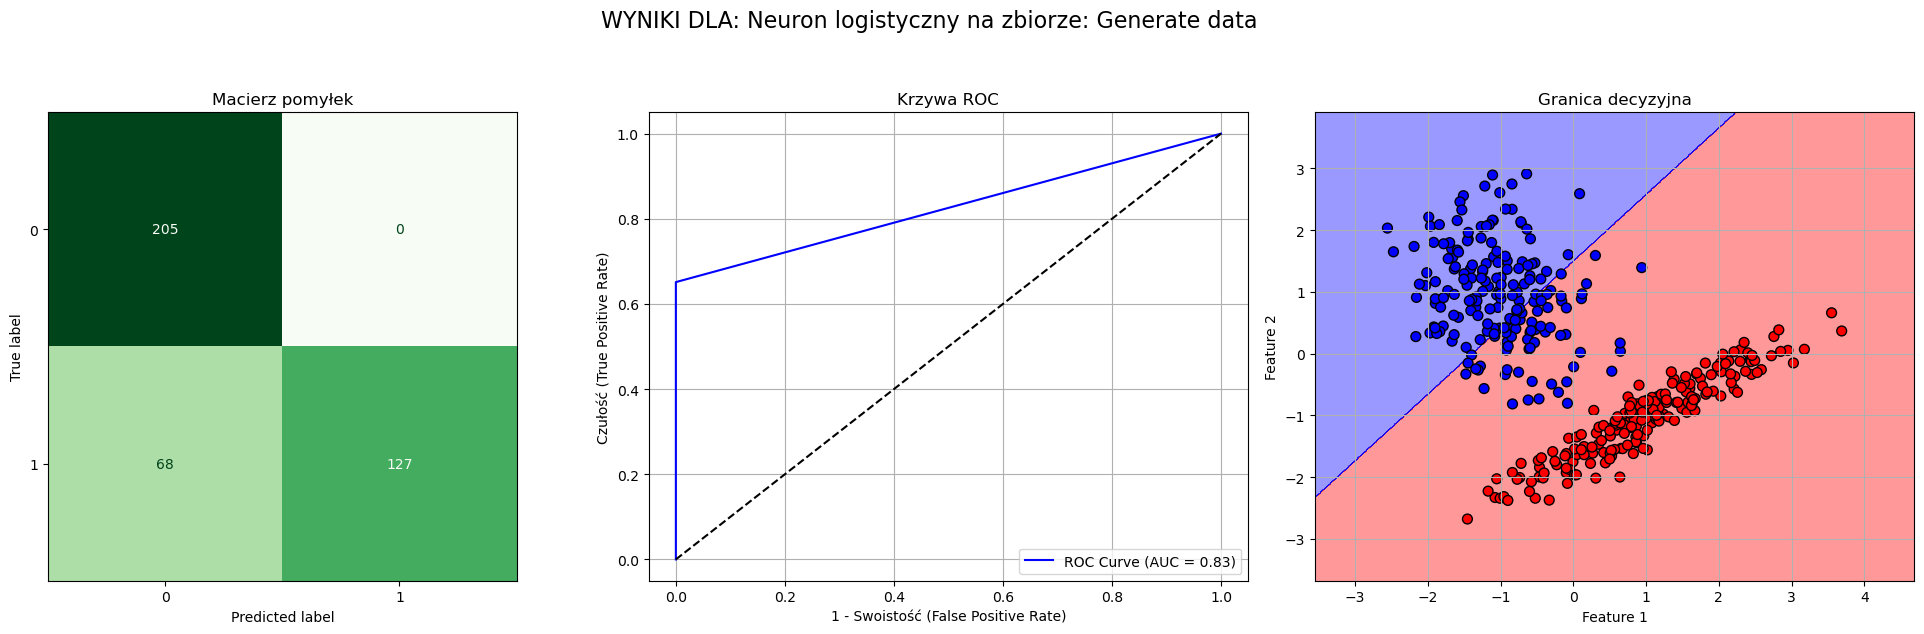

Wykres funkcji straty:


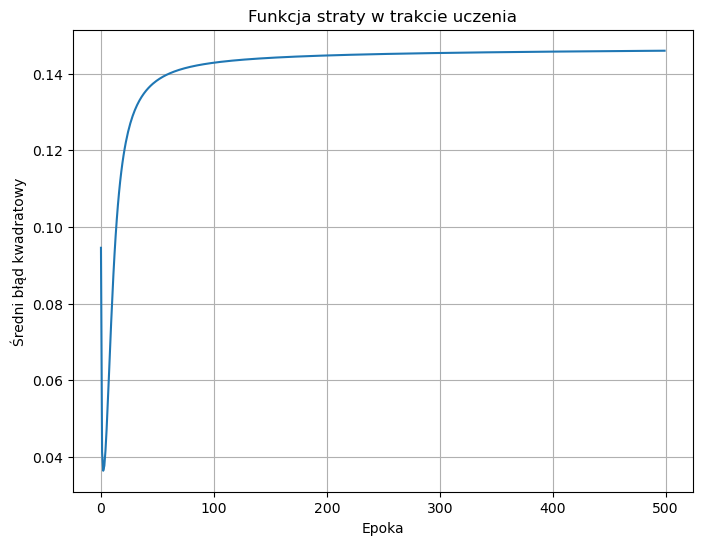

In [44]:
X_generate, y_generate = generate_data(2000, 2, 259195)
X_gen_train, X_gen_test, y_gen_train, y_gen_test = train_test_split(X_generate, y_generate, test_size=0.2, random_state=259195)

start = time.time()
for _ in range(1):
    neuron = LogisticNeuron(eta=0.01, max_epochs=500)
    neuron.train(X_gen_train, y_gen_train)
    y_gen_pred = neuron.predict(X_gen_test)
end = time.time()
print(f"Czas wykonania: {end - start:.6f} sekund")
evaluate_classifier(y_gen_test, y_gen_pred, X_gen_test, y_gen_test, neuron, "Neuron logistyczny", "Generate data", labels=[0, 1], decision_plot=True)

print("Wykres funkcji straty:")
plt.figure(figsize=(8, 6))
plt.plot(neuron.losses)
plt.title("Funkcja straty w trakcie uczenia")
plt.xlabel("Epoka")
plt.ylabel("Średni błąd kwadratowy")
plt.grid(True)

#### Testowanie na *make moons*:

Czas wykonania: 4.023730 sekund
Neuron logistyczny na Moons data:
Skuteczność: 53.5000%
Czułość (Recall): 100.0000%
Swoistość: 11.4286%
ROC AUC: 0.5571


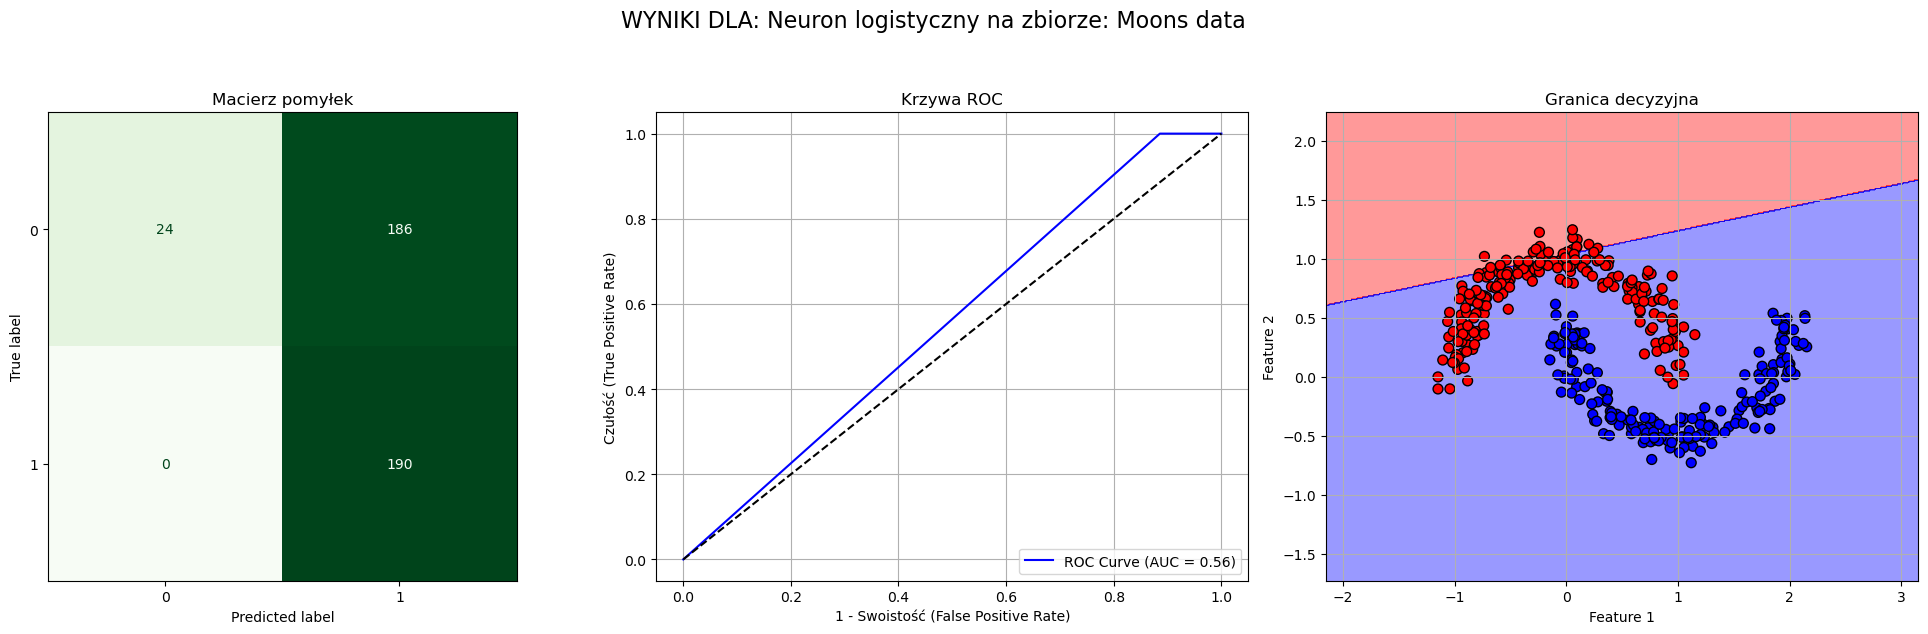

Wykres funkcji straty dla danych Moons:


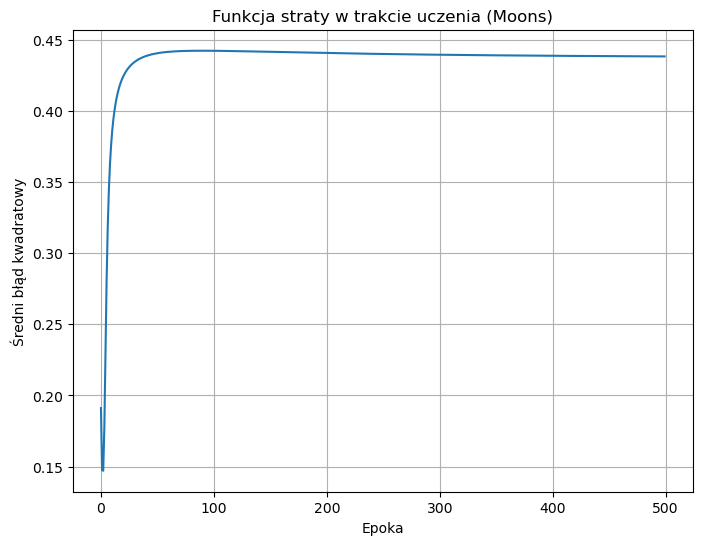

In [45]:
X_moons, y_moons = generate_moons(2000, 259195)
X_m_train, X_m_test, y_m_train, y_m_test = train_test_split(X_moons, y_moons, test_size=0.2, random_state=259195)

start = time.time()
for _ in range(1):
    neuron_moons = LogisticNeuron(eta=0.01, max_epochs=500)
    neuron_moons.train(X_m_train, y_m_train)
    y_m_pred = neuron_moons.predict(X_m_test)
end = time.time()
print(f"Czas wykonania: {end - start:.6f} sekund")
evaluate_classifier(y_m_test, y_m_pred, X_m_test, y_m_test, neuron_moons, "Neuron logistyczny", "Moons data", labels=[0, 1], decision_plot=True)
print("Wykres funkcji straty dla danych Moons:")
plt.figure(figsize=(8, 6))
plt.plot(neuron_moons.losses)
plt.title("Funkcja straty w trakcie uczenia (Moons)")
plt.xlabel("Epoka")
plt.ylabel("Średni błąd kwadratowy")
plt.grid(True)
